In [1]:
import os
from pathlib import Path

DATA_PATH = Path("../dataset/messy_mashup")

genres_path = DATA_PATH / "genres_stems"

genres = sorted(os.listdir(genres_path))

print("Genres:", genres)
print("Number of genres:", len(genres))

Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Number of genres: 10


### Verify Class Balance

In [2]:
from collections import defaultdict

song_counts = {}

for genre in genres:
    genre_dir = genres_path / genre
    songs = os.listdir(genre_dir)
    song_counts[genre] = len(songs)

song_counts

{'blues': 100,
 'classical': 100,
 'country': 100,
 'disco': 100,
 'hiphop': 100,
 'jazz': 100,
 'metal': 100,
 'pop': 100,
 'reggae': 100,
 'rock': 100}

In [3]:
missing_stems = []

expected = {"drums.wav", "vocals.wav", "bass.wav", "other.wav"}

for genre in genres:
    genre_dir = genres_path / genre
    
    for song in os.listdir(genre_dir):
        song_dir = genre_dir / song
        stems = set(os.listdir(song_dir))
        
        if stems != expected:
            missing_stems.append((genre, song, stems))

len(missing_stems)

0

### Inspect Audio Properties

In [4]:
import librosa
import numpy as np
import random

def inspect_audio(file_path):
    y, sr = librosa.load(file_path, sr=None)
    
    duration = len(y) / sr
    amp_min = np.min(y)
    amp_max = np.max(y)
    
    return {
        "sample_rate": sr,
        "duration": duration,
        "amp_min": amp_min,
        "amp_max": amp_max
    }

samples = []

for genre in genres:
    genre_dir = genres_path / genre
    songs = os.listdir(genre_dir)
    
    random_song = random.choice(songs)
    
    stem_path = genre_dir / random_song / "drums.wav"
    
    stats = inspect_audio(stem_path)
    stats["genre"] = genre
    
    samples.append(stats)

samples


d:\Projects\DLGenAi Project\dlgenaienv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[{'sample_rate': 44100,
  'duration': 30.013333333333332,
  'amp_min': np.float32(-0.3215332),
  'amp_max': np.float32(0.3002472),
  'genre': 'blues'},
 {'sample_rate': 44100,
  'duration': 30.013333333333332,
  'amp_min': np.float32(-0.00019836426),
  'amp_max': np.float32(0.00015258789),
  'genre': 'classical'},
 {'sample_rate': 44100,
  'duration': 30.013333333333332,
  'amp_min': np.float32(-0.50717163),
  'amp_max': np.float32(0.42129517),
  'genre': 'country'},
 {'sample_rate': 44100,
  'duration': 30.00018140589569,
  'amp_min': np.float32(-1.0),
  'amp_max': np.float32(0.9999695),
  'genre': 'disco'},
 {'sample_rate': 44100,
  'duration': 30.013333333333332,
  'amp_min': np.float32(-1.0),
  'amp_max': np.float32(0.9999695),
  'genre': 'hiphop'},
 {'sample_rate': 44100,
  'duration': 30.013333333333332,
  'amp_min': np.float32(-0.22573853),
  'amp_max': np.float32(0.1956482),
  'genre': 'jazz'},
 {'sample_rate': 44100,
  'duration': 30.00018140589569,
  'amp_min': np.float32(-0.

### Plot Waveform and Mel Spectrogram

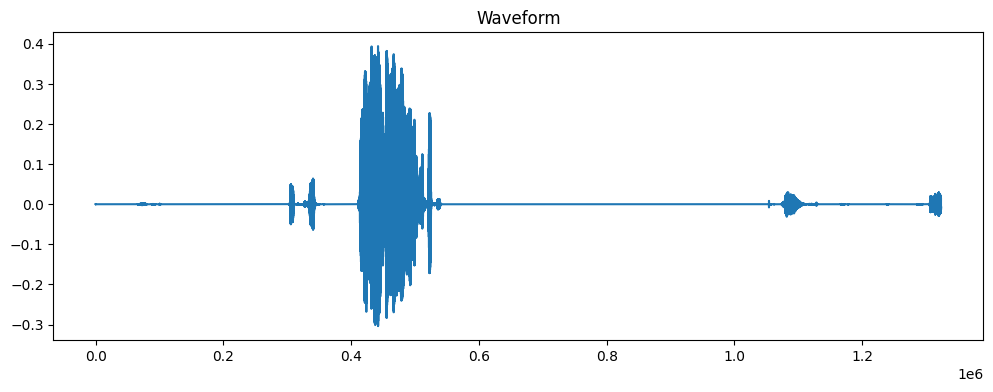

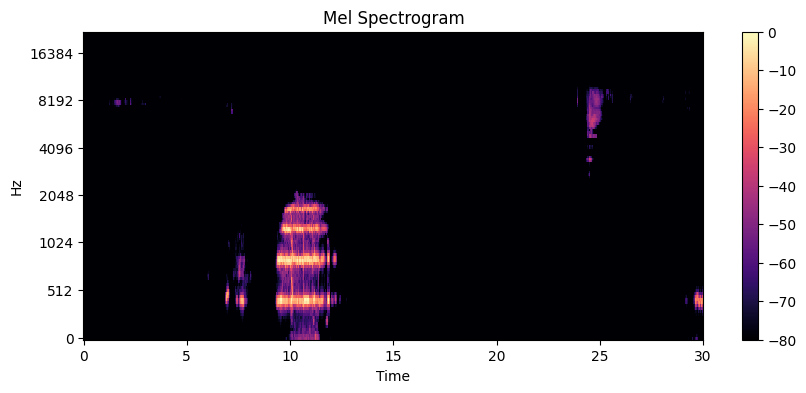

In [42]:
import sounddevice as sd
import soundfile as sf
path=r"D:\Projects\DLGenAi Project\dataset\messy_mashup\genres_stems\jazz\jazz.00005\vocals.wav"
data, fs = sf.read(path)
sd.play(data, fs)
# sd.wait()

import matplotlib.pyplot as plt

file_path = path

y, sr = librosa.load(file_path, sr=None)

plt.figure(figsize=(12,4))
plt.plot(y)
plt.title("Waveform")
plt.show()

import librosa.display

mel_spec = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_fft=2048,
    hop_length=512,
    n_mels=128
)

mel_db = librosa.power_to_db(mel_spec, ref=np.max)

plt.figure(figsize=(10,4))
librosa.display.specshow(
    mel_db,
    sr=sr,
    hop_length=512,
    x_axis='time',
    y_axis='mel'
)
plt.colorbar()
plt.title("Mel Spectrogram")
plt.show()

### Picking random audios from all genres and plotting a spectogram

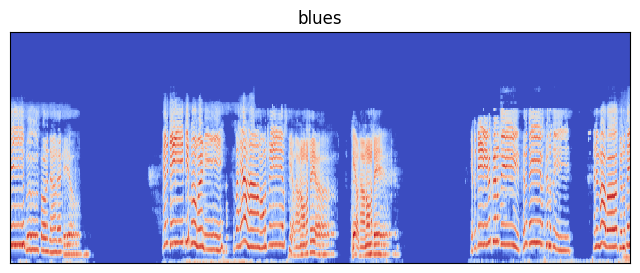

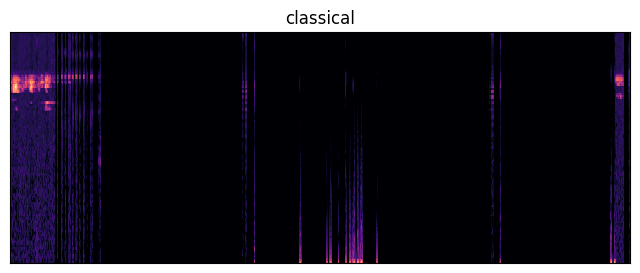

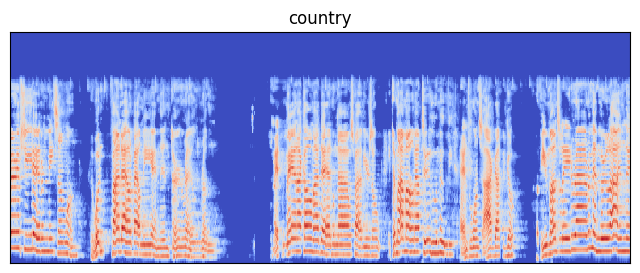

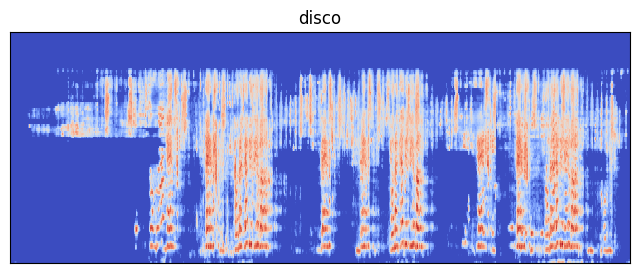

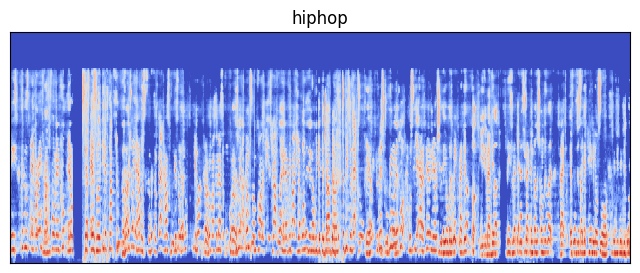

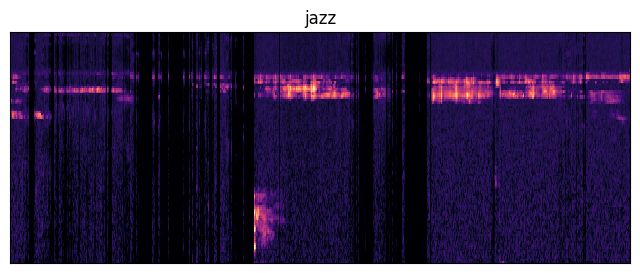

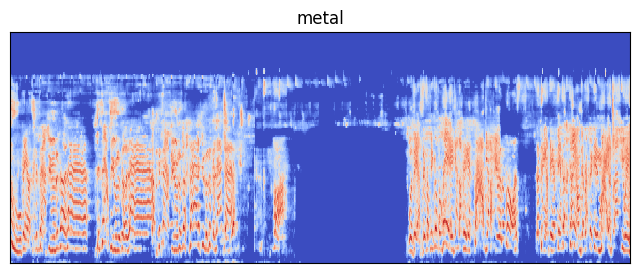

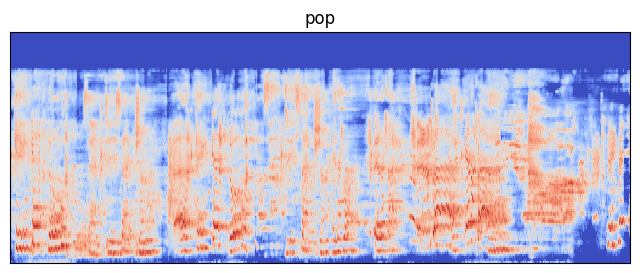

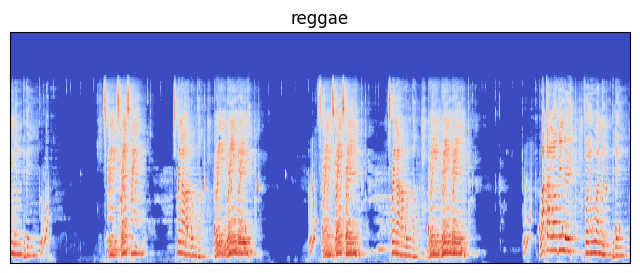

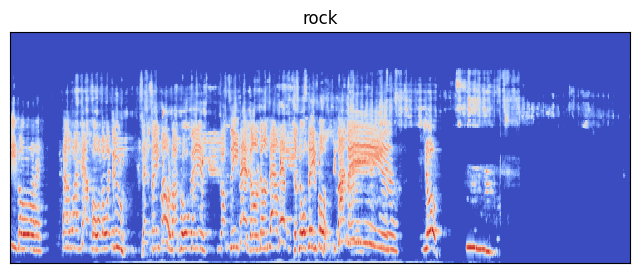

In [38]:
for genre in genres:
    genre_dir = genres_path / genre
    song = random.choice(os.listdir(genre_dir))
    
    file_path = genre_dir / song / "vocals.wav"
    
    y, sr = librosa.load(file_path, sr=None)
    
    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    mel_db = librosa.power_to_db(mel)
    
    plt.figure(figsize=(8,3))
    librosa.display.specshow(mel_db, sr=sr)
    plt.title(genre)
    plt.show()

### Inspect Noise Dataset

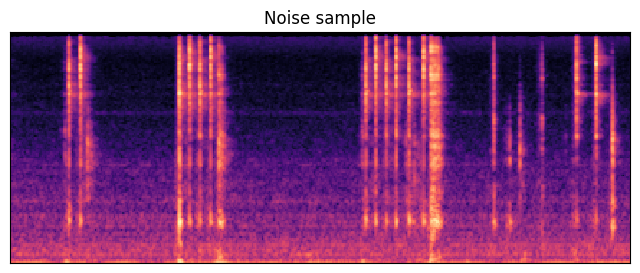

In [62]:
noise_path = DATA_PATH / "ESC-50-master/audio"

noise_files = os.listdir(noise_path)

sample_noise = random.choice(noise_files)

file_path = noise_path / sample_noise

data, fs = sf.read(file_path)
sd.play(data, fs)

y, sr = librosa.load(file_path, sr=None)

mel = librosa.feature.melspectrogram(y=y, sr=sr)
mel_db = librosa.power_to_db(mel)

plt.figure(figsize=(8,3))
librosa.display.specshow(mel_db, sr=sr)
plt.title("Noise sample")
plt.show()

## NOTES

All files use 44100 Hz sample rate.

Average stem duration ≈ 30 seconds.

Genres are perfectly balanced (100 songs each).

Stems contain strong frequency separation:
- drums → low frequency bursts
- vocals → mid harmonic bands

ESC-50 noise is broadband and overlaps with music frequencies.
Noise augmentation will therefore require careful SNR control.